In [1]:
# Enable autoreload of imported modules

%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
from pathlib import Path
import yaml
import spacy

def load_config(path):
    """
    Load event config file and data.

    Returns: Config `cfg` and DataFrame `df`.
    """
    config_file = path
    cfg = yaml.safe_load(Path(config_file).read_text(encoding='utf-8')).get('event', {})

    # Normalize keywords
    nlp = spacy.load("en_core_web_lg")
    doc = nlp(" ".join(cfg["keywords"]))
    cfg['keywords'] = [t.lemma_ for t in doc]

    # Check if cleaned file exists
    cleaned_path = Path(cfg['input_file'].replace('/raw/', '/clean/'))
    if cleaned_path.exists():
        print(f"Reading cleaned file: {cleaned_path}")
        cfg['cleaned_file'] = cleaned_path
        df = pd.read_csv(cleaned_path)
    else: 
        print(f"Reading raw file: {cfg['input_file']}")
        df = pd.read_csv(cfg['input_file'])

    return cfg, df

In [3]:
### Timing decorator
import time

def timing(func):
    def wrapper(*args, **kwargs):
        start = time.perf_counter()
        result = func(*args, **kwargs)
        end = time.perf_counter()
        print(f"{func.__name__} took {end - start:.4f} seconds")
        return result
    return wrapper


In [4]:
from preprocessing.normalize_text import normalize_text_series

def normalize_texts(df, batch_size=50, n_process=10):
    """
    Create clean text columns for 'title', 'text' and 'first_para'.
    """

    if 'title' in df:
        df['title_clean'] = normalize_text_series(df['title'], 
                                                  batch_size=batch_size, 
                                                  n_process=n_process)
    if 'text' in df:
        df['text_clean'] = normalize_text_series(df['text'], 
                                                  batch_size=batch_size, 
                                                  n_process=n_process)
    if 'first_para' in df:
        df['first_para_clean'] = normalize_text_series(df['first_para'], 
                                                  batch_size=batch_size, 
                                                  n_process=n_process)
    
    return df

In [5]:
from preprocessing.tfidf_dedupe import dedupe_tfidf_cosine

@timing
def dedupe_texts(df, text_col):
    """
    Dedupe entries in `df` with nearly identical values in `text_col`. Keeps the longest text by default.
    """
    threshold = 0.9
    min_df = 1  # min doc frequency
    ngram_min = 1
    ngram_max = 2
    max_features=None
    prefer_longer = True
    block_by_length = True  # compare only to similar length documents
    return_groups = True

    deduped_df, dedupe_report = dedupe_tfidf_cosine(
        df,
        text_col=text_col,
        threshold=threshold,
        min_df=min_df,
        ngram_min=ngram_min,
        ngram_max=ngram_max,
        max_features=max_features,
        prefer_longer=prefer_longer,
        block_by_length=block_by_length,
        return_groups=return_groups,
    )

    return deduped_df, dedupe_report

In [6]:
config_file = Path("config/elpaso.yaml")
cfg, df = load_config(config_file)

xlim = (-7,30)

root_dir = Path(".").absolute()

Reading cleaned file: data/event_data/clean/2019_elpaso_tx.csv


In [7]:
# Prepare output dir

save_output = True  # Save output files

output_dir = root_dir.joinpath(f"output/{config_file.stem}")
print(f"Output dir: {output_dir}")

if save_output:  # Make output_dir
    output_dir.mkdir(parents=True, exist_ok=True)

report = dict()
# report['cfg'] = cfg


Output dir: /home/mauricio/projects/HSMS_LUGOS/output/elpaso


In [8]:

# If we did not find a cleaned file, cleanup text
if not 'cleaned_file' in cfg:
    # Normalize text columns
    df = normalize_texts(df)
    # Dedupe DF
    df, report_text = dedupe_texts(df, text_col='text_clean')
    df, report_title = dedupe_texts(df, text_col='title_clean')
    df, report_para = dedupe_texts(df, text_col='first_para')

    print(f"Documents after deduping: {len(df)}")

report["docs_clean"] = len(df)

In [9]:
# Make datetime indices and filters
df.index = pd.DatetimeIndex(pd.to_datetime(df["date"], format="%Y%m%d"))
df = df.sort_index()
df = df[cfg['start_date']: cfg['end_date']]

# Drop datetime indices
df = df.reset_index(drop=True)
df["date"] = pd.to_datetime(df["date"], format="%Y%m%d")
df = df.sort_values("date")
# dates = df["date"]


In [10]:
# Normalize time (t=-7 to t=+30), aggregate per day
from typing import Tuple
from datetime import datetime

def normalize_time(df: pd.DataFrame,
                   date_col: str = 'date',
                   onset_date: datetime = None):
    """
    Normalize date column and convert it to discrete time indices.
    """
    if onset_date is None:
        print(f"Must inform onset_date!")
        exit(1)
    onset_date = pd.to_datetime(onset_date)
    
    norm_time = (df[date_col] - onset_date).dt.days
    return norm_time

df['norm_date'] = normalize_time(df, 'date', cfg['onset_date'])
df['norm_date']

0        -8
252      -8
251      -8
250      -8
249      -8
         ..
12307    31
12306    31
12305    31
12314    31
12565    31
Name: norm_date, Length: 12566, dtype: int64

In [11]:
texts = (df['title_clean'].fillna("") + ". " + df['first_para_clean'].fillna(""))  # .tolist()
# texts = (df['title_clean'].fillna(""))  # .tolist()



In [12]:
### Count documents containing seed keywords

import re
from collections import Counter

# Get seed word list from config and normalize to match cleaned texts
seed_words_raw = cfg.get('keywords', [])
# Normalize: lowercase, strip non-alpha (same style as clean_text_regex)
seed_words = []
for w in seed_words_raw:
    w_norm = re.sub(r'[^a-z\s]', '', str(w).lower()).strip()
    if w_norm:
        seed_words.append(w_norm)

seed_words = sorted(set(seed_words))

# 3) Tokenize each cleaned text into a list of words (whitespace split)
def tokenize_cleaned(s: str):
    # 'texts' are already cleaned (lowercase, non-alpha removed, stopwords removed)
    return s.split()

seed_set = set(seed_words)

doc_seed_hits_detail = []
doc_seed_hits_count = []
doc_seed_hits_unique = []

for s in texts:
    toks = tokenize_cleaned(s)
    # Count only tokens that are seeds
    hits = [t for t in toks if t in seed_set]
    cnt = Counter(hits)
    doc_seed_hits_detail.append(cnt)              # Counter dict per doc
    doc_seed_hits_count.append(sum(cnt.values())) # total matches
    doc_seed_hits_unique.append(len(cnt.keys()))  # unique seeds matched

# Attach to df (aligned by row)
df["seed_hits_count"] = doc_seed_hits_count
df["seed_hits_unique"] = doc_seed_hits_unique
# To store a JSON-friendly form of the dict:
df["seed_hits_detail"] = [dict(c) for c in doc_seed_hits_detail]

print(f"Documents with >= 1 seed hit: {(df['seed_hits_count']>0).sum()}/{len(df)}")

Documents with >= 1 seed hit: 3318/12566


/home/mauricio/projects/HSMS_LUGOS


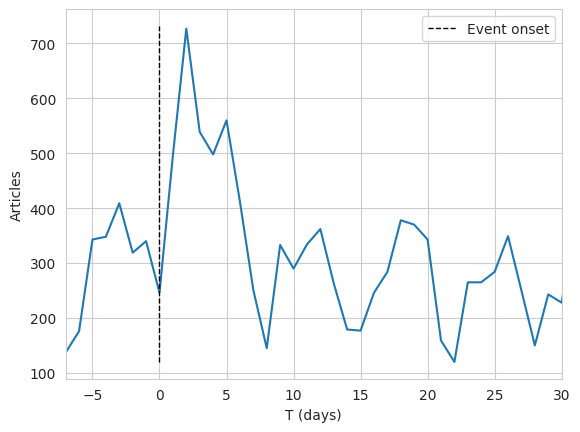

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("whitegrid")
# articles_per_day = df.resample('1D', on="date")['GlobalEventID'].count().plot();
articles_per_day = df.groupby('norm_date')['GlobalEventID'].count();

plt.clf()
fig = sns.lineplot(data=articles_per_day);
plt.xlabel("T (days)")
plt.ylabel("Articles")
plt.xlim(*xlim)
plt.vlines((0), ymin=min(articles_per_day), ymax=max(articles_per_day+5), linestyles='--', colors='black', linewidth=1, label='Event onset');
plt.legend();


if save_output:
    print(Path(".").absolute())
    plt.savefig(output_dir.joinpath("articles_per_day.pdf"))
    

In [14]:
from sentence_transformers import SentenceTransformer

# load embeddings
model_name = "sentence-transformers/all-MiniLM-L6-v2"
embedder = SentenceTransformer(model_name)
embeddings = embedder.encode(texts, batch_size=128, show_progress_bar=True)

/home/mauricio/miniconda3/envs/cuda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Batches: 100%|██████████| 99/99 [00:07<00:00, 12.72it/s]


In [15]:
## Filter only documents with some seed hit


seed_mask = df['seed_hits_count'] >= 2
print(f"Documents in: {seed_mask.sum()} | out: {(1-seed_mask).sum()}")

## Before we drop documents from the dataset, let us find those with high SBERT similarity to seed-hit docs

# Compute the nearest neighbors of each non-seed documents and flip it if the majority is in-topic.
from analysis.topic_modeling import knn_majority_flip

new_mask, details = knn_majority_flip(embeddings, seed_mask)

print(f"Before join: {seed_mask.sum()}. After join: {new_mask.sum()}")

report['docs_after_join'] = int(new_mask.sum())

Documents in: 2167 | out: 10399
Before join: 2167. After join: 2332


In [16]:
# Split dataframes
import numpy as np


df['row_id'] = np.arange(len(df))
df['is_event'] = new_mask

df_in = df[new_mask]
# texts_in = texts[new_mask].copy().reset_index(drop=True)
texts_in = texts[new_mask]
embeddings_in = embeddings[new_mask]

df_out = df[~new_mask]
texts_out = texts[~new_mask]
embeddings_out = embeddings[~new_mask]



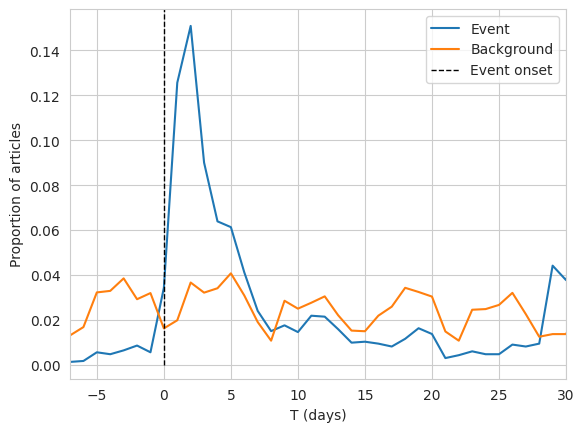

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# dts = sorted(df['norm_date'].unique())
# articles_per_day_in = [len(df_in[df_in['norm_date']==d])/len(df_in) for d in dts]
# articles_per_day_out = [len(df_out[df_out['norm_date']==d])/len(df_out) for d in dts]
articles_per_day_in = df_in['norm_date'].value_counts(normalize=True)
articles_per_day_out = df_out['norm_date'].value_counts(normalize=True)

max_y = max(max(articles_per_day_in), max(articles_per_day_out))


plt.clf();
plt.xlim(*xlim)
sns.lineplot(data=articles_per_day_in, label="Event")
sns.lineplot(data=articles_per_day_out, label="Background")
plt.autoscale(False)  # Set autoscale before drawing vertical line
plt.vlines((0), ymin=0, ymax=1, linestyles='--', colors='black', linewidth=1, label='Event onset')
plt.ylabel("Proportion of articles")
plt.xlabel("T (days)")
plt.legend();

if save_output:
    plt.savefig(output_dir.joinpath("event_articles_per_day.pdf"));


In [18]:
# Centroid functions
from numpy.linalg import norm
import numpy as np


def cosine_distance(a: np.ndarray, b: np.ndarray) -> float:
    na, nb = norm(a), norm(b)
    if na == 0 or nb == 0:
        return np.nan
    return 1.0 - float(np.dot(a, b) / (na * nb))



def geometric_median(X, eps=1e-5, max_iter=200):
    # X: (n, d)
    y = X.mean(axis=0)
    for _ in range(max_iter):
        d = np.linalg.norm(X - y, axis=1)
        # Avoid division by zero
        d = np.where(d < eps, eps, d)
        w = 1.0 / d
        y_new = (w[:, None] * X).sum(axis=0) / w.sum()
        if np.linalg.norm(y_new - y) < eps:
            break
        y = y_new
    return y


def compute_daily_centroids(df, embeddings, centroid_method: str = "mean") -> pd.DataFrame:
    """
    Compute the centroids for each day for a given topic dataframe.

    Args:
        df (pd.DataFrame): input topic dataframe.
        embeddings (np.ndarray[float]) : The document embeddings.
        centroid_method (str) : The centroid calculation method {'mean' or 'median'}.
    Returns:
    """
    ## Compute the centroids for each day

    daily_centroids = []
    groups = df.groupby(df["norm_date"])
    for gdate, gdf in groups:
        pos_idx = gdf["row_id"].to_numpy()  # Get row positions in original df
        # Find local positions for embeddings
        local_idx = df.index.get_indexer(gdf.index)        # positions within df_topic    
        emb_day = embeddings[local_idx]  # Get embeddings for this date
        if emb_day.size == 0:
            continue
        if centroid_method == "mean":
            centroid_sbert = emb_day.mean(axis=0)  # Compute centroid
        elif centroid_method == "median":
            centroid_sbert = geometric_median(emb_day)
        else:
            print(f"Invalid centroid_method: {centroid_method}")
            exit(1)
        daily_centroids.append({
            "date_str": gdate,
            "emb": centroid_sbert,
            "date": gdf["date"].min(),
            "n_docs": len(emb_day)
        })


    # Convert to DataFrame and sort chronologically
    cent_df = pd.DataFrame(daily_centroids)
    # Normalize date: if 'date' is an int/string in YYYYMMDD format, convert to datetime
    cent_df["dt"] = cent_df['date_str']
    cent_df = cent_df.sort_values("dt").reset_index(drop=True)

    return cent_df


def smoothen_centroids_and_dist(cent_df: pd.DataFrame) -> pd.DataFrame:
    #  Exponential Moving Average (EMA) smoothing of centroids (vector EMA)
    use_vol_scale = True

    vol_scale = np.percentile(cent_df["n_docs"], 75)  # robust target volume
    base_alpha = 0.20  # Lower = smoother

    ema = []
    prev = None
    for i, row in cent_df.iterrows():
        c = row["emb"]  # numpy 1D vector
        n = row["n_docs"]
        # Adjust alpha per number of documents on that day / cap at [min_alpha, base_alpha]
        if use_vol_scale:
            adj_alpha = base_alpha * min(1.0, n / vol_scale)
            adj_alpha = max(0.05, adj_alpha)  # avoid freezing on small n
        else:
            adj_alpha = base_alpha

        if prev is None:
            s = c.copy()           # initialize EMA with first day's centroid
        else:
            s = adj_alpha * c + (1.0 - adj_alpha) * prev
        ema.append(s)
        prev = s

    cent_df["centroid_ema"] = ema  # attach smoothed centroid


    # Distance between consecutive smoothed centroids (main stability signal)
    dist_smooth = [np.nan]
    for i in range(1, len(cent_df)):
        d = cosine_distance(cent_df.loc[i, "centroid_ema"], cent_df.loc[i-1, "centroid_ema"])
        dist_smooth.append(d)
    cent_df["dist_smooth_to_prev_smooth"] = dist_smooth

    # Distance between raw centroid and previous day's smoothed centroid (outlier sensitivity)
    dist_raw_to_prev_smooth = [np.nan]
    for i in range(1, len(cent_df)):
        d = cosine_distance(cent_df.loc[i, "emb"], cent_df.loc[i-1, "centroid_ema"])
        dist_raw_to_prev_smooth.append(d)
    cent_df["dist_raw_to_prev_smooth"] = dist_raw_to_prev_smooth

    return cent_df

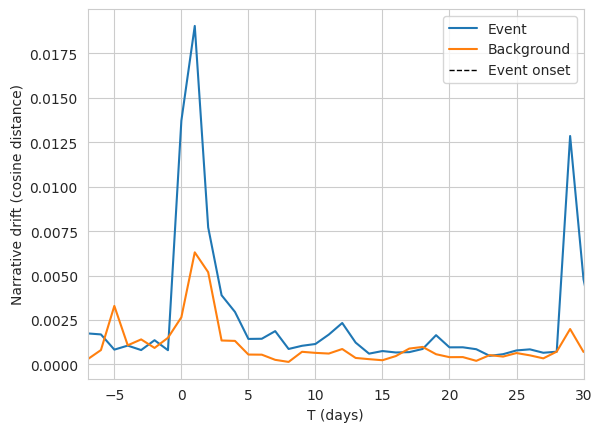

In [19]:
# Retrieve subsets of DataFrame and embeddings
import matplotlib.pyplot as plt

# ## Compute the centroids for each day
cent_df = compute_daily_centroids(df_in, embeddings_in)
cent_df = smoothen_centroids_and_dist(cent_df)


## Compute non-topic centroids
cent_df_c = compute_daily_centroids(df_out, embeddings_out)
cent_df_c = smoothen_centroids_and_dist(cent_df_c)

y_col = 'dist_smooth_to_prev_smooth'

plt.clf();
plt.xlim(*xlim)
sns.lineplot(data=cent_df, x='dt', y=y_col, label='Event');
# plt.xticks(rotation=45);

sns.lineplot(data=cent_df_c, x='dt', y=y_col, label='Background')
# plt.xticks(rotation=45);
plt.vlines((0), ymin=0, ymax=max(cent_df[y_col]), linestyles='--', colors='black', linewidth=1, label='Event onset')
plt.legend()
plt.ylabel('Narrative drift (cosine distance)')
plt.xlabel('T (days)');

if save_output:
    plt.savefig(output_dir.joinpath("narrative_drift.pdf"))




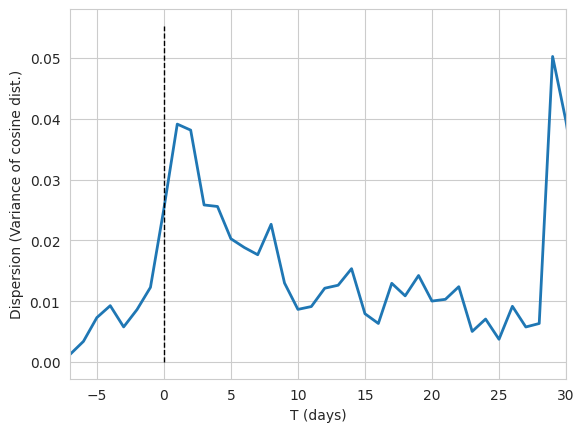

In [20]:
### Plot dispersion

from analysis.dispersion import get_centroid_dispersion_per_day

dispersion = get_centroid_dispersion_per_day(df_in, embeddings_in)
cent_df['dispersion'] = dispersion

plt.clf()
sns.lineplot(data=cent_df, x='dt', y='dispersion', linewidth=2)
plt.xlabel("T (days)")
plt.ylabel("Dispersion (Variance of cosine dist.)")
plt.xlim(*xlim)
plt.vlines((0), ymin=0, ymax=max(dispersion*1.1), linestyles='--', colors='black', linewidth=1, label='Event onset');

if save_output:
    plt.savefig(output_dir.joinpath("narrative_dispersion.pdf"))



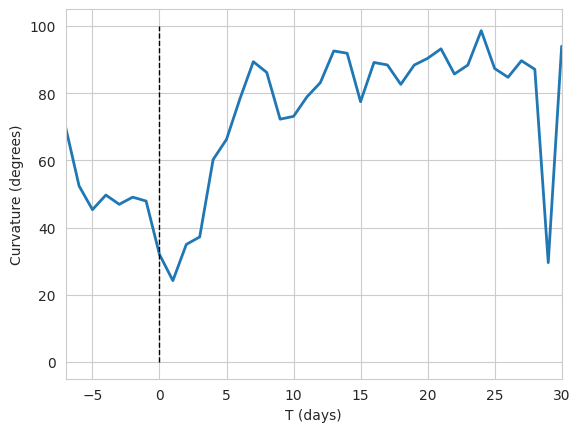

In [21]:
### Get daily curvatures
from analysis.dispersion import compute_curvature

curvatures = compute_curvature(cent_df['centroid_ema'], output_unit='degrees')
cent_df['curvature'] = curvatures

plt.clf()
sns.lineplot(data=cent_df, x='dt', y='curvature', linewidth=2)
plt.xlabel("T (days)")
plt.ylabel("Curvature (degrees)")
plt.xlim(*xlim)
plt.vlines((0), ymin=0, ymax=100, linestyles='--', colors='black', linewidth=1, label='Event onset');

if save_output:
    plt.savefig(output_dir.joinpath("narrative_curvature.pdf"))

In [22]:
# Compute drift from baseline anchor (t < 0)


def get_drift_from_anchor(cent_df, anchor_emb, centroid_col='centroid_ema'):
    """
    Returns the drift from the anchor using centroids in `cent_df`.
    """

    drifts = cent_df[centroid_col].apply(lambda v: cosine_distance(v, anchor_emb))
    return drifts
    

def get_baseline_drift(cent_df, cent_df_c):
    """
    Return the 
    """
    baseline_anchor = np.mean(cent_df_c['centroid_ema'].iloc[:7], axis=0)
    return get_drift_from_anchor(cent_df, baseline_anchor)



In [23]:
event_baseline_drift = get_baseline_drift(cent_df, cent_df_c)
cent_df['drift_from_baseline'] = event_baseline_drift

bg_baseline_drift = get_baseline_drift(cent_df_c, cent_df_c)
cent_df_c['drift_from_baseline'] = bg_baseline_drift


In [24]:
### Dump report and daily dataframe
import json

print(report)
if save_output:
    cent_df.to_csv(output_dir.joinpath("daily_event.csv"), index=None)
    cent_df_c.to_csv(output_dir.joinpath("daily_background.csv"), index=None)
    with open(output_dir.joinpath("report.json"), "w") as fout:
        fout.write(json.dumps(report))

    print("Saved all output!")

{'docs_clean': 12826, 'docs_after_join': 2332}
Saved all output!


In [25]:
from analysis.topic_modeling import init_bertopic_model
import numpy as np
from analysis.topic_modeling import reassign_outliers

topic_model = init_bertopic_model(cfg['keywords'], seed_multiplier=1.0)
topics, probs = topic_model.fit_transform(texts_in.reset_index(drop=True), embeddings_in)

topic_info = topic_model.get_topic_info()

df_in['topic'] = topics

# Reassign outliers

reassign_outliers(df_in, probs, reassign_prob=0.25)




Outliers before reassign: 723
Outliers after reassign: 348


In [26]:
# # # === Analyze topic coverage of seed hits
from analysis.topic_modeling import get_topic_coverage_of_seeds

topic_seed_coverage = get_topic_coverage_of_seeds(df_in, topic_model, cfg['keywords'])

if save_output:
    topic_seed_coverage.to_csv(output_dir.joinpath("topic_coverage.csv"), index=None)

In [27]:
from analysis.topic_modeling import daily_topic_purity

topic_purity = daily_topic_purity(df_in)


In [28]:
from analysis.topic_modeling import daily_topic_counts

topic_counts = daily_topic_counts(df_in)

# sns.lineplot(data=topic_counts, x="day", y="n_docs_topic_day", hue="topic");

In [29]:
## Analyze subtopic lexical coherence using topic word overlap

from analysis.subtopic import day_lexical_coherence

lexical_coherence = day_lexical_coherence(df_in, topic_model)


In [30]:
# Calculate smoothed topic centroids

def compute_daily_topic_centroids(df, embeddings, centroid_method: str = "mean") -> pd.DataFrame:
    """
    Compute the centroids for each day for a given topic dataframe.

    Args:
        df (pd.DataFrame): input topic dataframe.
        embeddings (np.ndarray[float]) : The document embeddings.
        centroid_method (str) : The centroid calculation method {'mean' or 'median'}.
    Returns:
    """
    ## Compute the centroids for each day

    daily_centroids = []
    groups = df.groupby(["norm_date", "topic"])
    for gidx, gdf in groups:
        day, topic = gidx
        if topic == -1:  # Skip this topic
            continue
        # Find local positions for embeddings
        local_idx = df.index.get_indexer(gdf.index)        # positions within df_topic    
        emb_day = embeddings[local_idx]  # Get embeddings for this date
        if emb_day.size == 0:
            continue
        if centroid_method == "mean":
            centroid_sbert = emb_day.mean(axis=0)  # Compute centroid
        elif centroid_method == "median":
            centroid_sbert = geometric_median(emb_day)
        else:
            print(f"Invalid centroid_method: {centroid_method}")
            exit(1)
        daily_centroids.append({
            "day": day,
            "topic": topic,
            "emb": centroid_sbert,
            "date": gdf["date"].min(),
            "n_docs": len(emb_day)
        })


    # Convert to DataFrame and sort chronologically
    cent_df = pd.DataFrame(daily_centroids)
    # Normalize date: if 'date' is an int/string in YYYYMMDD format, convert to datetime
    cent_df["dt"] = cent_df['day']
    cent_df = cent_df.sort_values("dt").reset_index(drop=True)

    return cent_df

In [31]:
from analysis.dispersion import smoothen_centroids_and_dist_per_topic
cent_topics = compute_daily_topic_centroids(df_in, embeddings_in)
cent_topics = smoothen_centroids_and_dist_per_topic(cent_topics)


In [32]:
# Analyzing subtopic coherence with embeddings
from analysis.subtopic import subtopic_coherence_embedding

coherence_per_topic, coherence_agg = subtopic_coherence_embedding(df_in, embeddings_in)



In [33]:

topics_daily = topic_counts
topics_daily = topics_daily.merge(coherence_per_topic, 
                                left_on=['day', 'topic'], 
                                right_on=['day', 'topic'],
                                how='left')

topics_daily = topics_daily.merge(cent_topics,
                                  left_on=["day", "topic"],
                                  right_on=["day", "topic"],
                                  how="left")

if save_output:
    topics_daily.to_csv(output_dir.joinpath("topics_daily.csv"), index=None)

[2, 8, 37] 2.3547199422591354
40 40 -8
[14, 29, 36] 4.600932338499861
40 40 -8
[8, 27, 31, 37] 1.8198926572883252
40 40 -8
[2, 8, 32, 37] 1.303351441920558
40 40 -8
[1, 37] 1.1178721846256072
40 40 -8


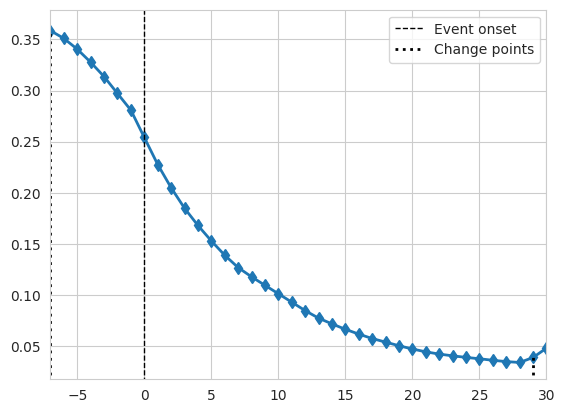

In [86]:
### Perform changepoint detection of univariate signals

from analysis.changepoint import percentile_bursts, preprocess_signal, binary_segmentation_mean, detect_cp_abs_dev


burst_method = "percentile"
preprocess_input = True

signals = ["dist_smooth_to_prev_smooth", "n_docs",
           "dispersion", "curvature", "drift_from_baseline"]

cp_results = list()
for signal_col in signals:
    if preprocess_input:
        x_signal = preprocess_signal(cent_df[signal_col])
    else:
        x_signal = cent_df[signal_col]
        
    if burst_method == "percentile":
        cp, rscore, thr = percentile_bursts(x_signal, 
                                            q=90, 
                                            window=3,
                                            location="median")
        print(cp, thr)
        print(len(x_signal), len(cent_df), min(cent_df['dt']))
    elif burst_method == "binary":
        cp = binary_segmentation_mean(x_signal)
        rscore = None
        thr = None
    else:
        print("Error: Invalid burst detection method!")
        exit(1)

    cp_shifted = np.array(cp)+min(cent_df['dt'])  # Shift change points to -7
    plt.clf()
    # sns.lineplot(data=cent_df, x="dt", y=signal_col, linewidth=2);
    plt.plot(cent_df['dt'], x_signal, linewidth=2, marker='d')
    # plt.plot(cent_df['dt'], rscore)
    plt.xlim(*xlim)
    plt.autoscale(False)  # Set autoscale before drawing vertical line
    plt.vlines(0, ymin=0, ymax=max(x_signal+1), linestyles='--', colors='black', linewidth=1, label='Event onset');
    plt.vlines(cp_shifted, ymin=0, ymax=x_signal[cp], linestyles=':', colors='black', linewidth=2, label='Change points');
    plt.legend();

    cp_results.append(
        {"signal": signal_col,
         "cp": cp,
         "thr": thr,
         "rscores": ""}
    )

    if save_output:
        pd.DataFrame(cp_results).to_csv(output_dir.joinpath(f"cp_results.csv"), index=None)
        plt.savefig(output_dir.joinpath(f"cp_{signal_col}.pdf"))